---
title: "The Silent Crisis"
subtitle: "Global Child Deprivation and Mortality - A UNICEF Data Story"
author: "Shashank Ramesh"
date: "2026-04-14"
format:
  html:
    theme: pulse
    embed-resources: true
    code-fold: true
    toc: true
    toc-title: "Report Contents"
    toc-depth: 3
    fig-width: 10
    fig-height: 6
execute:
  warning: false
  message: false
  echo: true
---


In [1]:
#| label: install quarto
#| output: false
!pip install quarto-cli

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.9 MB/s eta 0:00:00
  Created wheel for quarto-cli: filename=quarto_cli-1.9.37-py3-none-any.whl size=137914927 sha256=38531205db6bb8b775abab84b64f78f19c53cc2732756ead02a17f8e1ba6b8cd
  Stored in directory: /root/.cache/pip/wheels/a7/11/48/00d62189ff1558eb09346e362e4604e16135a8b92076691a8b
Successfully built quarto-cli


In [2]:
#| label: setup data
#| output: false

from google.colab import drive
drive.mount("/content/drive")

path = "/content/drive/MyDrive/Unisef_data/"



Mounted at /content/drive


In [3]:
#| label: setup
#| output: false
#| code-summary: "Load packages and UNICEF datasets"

import polars as pl
import geopandas as gpd
import pandas as pd
from plotnine import (
    ggplot, aes, geom_map, geom_col, geom_point, geom_line,
    geom_smooth, geom_text, annotate,
    scale_fill_gradient, scale_fill_manual, scale_color_manual,
    scale_x_continuous, scale_y_continuous,
    coord_flip, labs, theme, theme_minimal, theme_bw, theme_light,
    element_blank, element_text, element_rect, element_line,
    facet_wrap
)

# Load the UNICEF datasets

# Indicator 1: Child mortality rate
# Indicator 2: % children suffering deprivations
# Metadata: Country-level variables

mortality_raw = pl.read_csv(path + "unicef_indicator_1.csv")
deprivation_raw = pl.read_csv(path + "unicef_indicator_2.csv")
metadata_raw = pl.read_csv(path + "unicef_metadata.csv")

print(f"Mortality records: {mortality_raw.shape[0]:,}  |  "
      f"Deprivation records: {deprivation_raw.shape[0]:,}  |  "
      f"Metadata records: {metadata_raw.shape[0]:,}")


Mortality records: 20,298  |  Deprivation records: 216  |  Metadata records: 13,715


In [5]:
#| label: data-transform
#| output: false
#| code-summary: "Data cleaning, joining, and EDA"

#  1. Filter for 'Total' sex to avoid double-counting
mortality = mortality_raw.filter(pl.col("sex") == "Total")
deprivation = deprivation_raw.filter(pl.col("sex") == "Total")

#  2. Rename obs_value to meaningful names before joining
mortality = mortality.rename({"obs_value": "mortality_rate"})
deprivation = deprivation.rename({"obs_value": "deprivation_pct"})

#  3. Join mortality + metadata on (country, year)
mort_meta = mortality.join(
    metadata_raw,
    left_on=["country", "time_period"],
    right_on=["country", "year"],
    how="left"
)

#  4. Join the deprivation indicator
# deprivation only has a single time_period per country, so we join on country only
# and use the most recent deprivation value per country
dep_latest = (
    deprivation
    .sort("time_period", descending=True)
    .unique(subset=["country"], keep="first")   # keep most-recent year
    .select(["country", "alpha_3_code", "deprivation_pct"])
)

full_data = mort_meta.join(
    dep_latest.select(["country", "deprivation_pct"]),
    on="country",
    how="left"
)

# 5. Exploratory statistics
stats = full_data.select([
    pl.col("mortality_rate").mean().round(3).alias("avg_mortality_all_years"),
    pl.col("mortality_rate").max().round(3).alias("max_mortality"),
    pl.col("mortality_rate").min().round(3).alias("min_mortality"),
    pl.col("deprivation_pct").drop_nulls().max().round(3).alias("max_deprivation"),
    pl.col("country").n_unique().alias("n_countries"),
])
print(stats)

# Most recent year average
avg_2023 = (
    mortality.filter(pl.col("time_period") == 2023)
    .select(pl.col("mortality_rate").mean().round(3))
    .item()
)
print(f"\nAvg Child Mortality Rate (2023): {avg_2023}")
print(f"Total unique countries in dataset: {mortality.select('country').n_unique()}")

# High-deprivation countries (> 1.0%)
extreme_dep = full_data.filter(pl.col("deprivation_pct") > 1.0).select("country").unique()
print(f"\nCountries with extreme deprivation (>1.0%): {extreme_dep.to_series().to_list()}")

# A) Top 10 countries by average child mortality rate (all years)
top10_mortality = (
    mortality
    .group_by("country")
    .agg(pl.col("mortality_rate").mean().round(2).alias("avg_mortality"))
    .sort("avg_mortality", descending=True)
    .head(10)
)

# B) Top 10 countries by deprivation
top10_deprivation = (
    dep_latest
    .sort("deprivation_pct", descending=True)
    .head(10)
)

# C) Global time trend
global_trend = (
    mortality
    .group_by("time_period")
    .agg(pl.col("mortality_rate").mean().round(3).alias("avg_mortality"))
    .sort("time_period")
)

# D) High-risk country time series
high_risk_countries = ["Rwanda", "Somalia", "South Sudan"]
high_risk_trend = (
    mortality
    .filter(pl.col("country").is_in(high_risk_countries))
    .group_by(["country", "time_period"])
    .agg(pl.col("mortality_rate").mean().round(2).alias("avg_mortality"))
    .sort(["country", "time_period"])
)

# E) Scatter data: deprivation vs mortality (country averages)
scatter_data = (
    full_data
    .group_by("country")
    .agg([
        pl.col("mortality_rate").mean().round(2).alias("avg_mortality"),
        pl.col("deprivation_pct").first().alias("deprivation_pct"),
    ])
    .drop_nulls()
)

# F) World map data: latest available mortality per country
map_data = (
    mortality
    .sort("time_period", descending=True)
    .unique(subset=["country"], keep="first")
    .select(["country", "alpha_3_code", "mortality_rate"])
)

print("\nData preparation complete.")


shape: (1, 5)
┌─────────────────────────┬───────────────┬───────────────┬─────────────────┬─────────────┐
│ avg_mortality_all_years ┆ max_mortality ┆ min_mortality ┆ max_deprivation ┆ n_countries │
│ ---                     ┆ ---           ┆ ---           ┆ ---             ┆ ---         │
│ f64                     ┆ f64           ┆ f64           ┆ f64             ┆ u32         │
╞═════════════════════════╪═══════════════╪═══════════════╪═════════════════╪═════════════╡
│ 8.758                   ┆ 339.412       ┆ 0.436         ┆ 1.426           ┆ 199         │
└─────────────────────────┴───────────────┴───────────────┴─────────────────┴─────────────┘

Avg Child Mortality Rate (2023): 5.147
Total unique countries in dataset: 199

Countries with extreme deprivation (>1.0%): ['Ethiopia', 'Madagascar']

Data preparation complete.


## Introduction

> *"Every year, millions of children die before their fifteenth birthday -  not from incurable diseases,*
> *but from entirely preventable causes rooted in poverty, inequality, and neglect."*

This report analyses **UNICEF data** on child mortality (deaths per 1,000 children aged 5–14) and
**multidimensional child deprivation** (% of children suffering from ≥5 simultaneous deprivations)
across **199 countries** over three decades (1990–2023).

Our analysis reveals three key findings:

1. **Geography matters enormously.** Sub-Saharan Africa and parts of South Asia bear a
   disproportionate burden, while wealthy nations have near-zero rates.
2. **Deprivation drives mortality.** There is a clear, statistically significant positive relationship
   between multidimensional poverty and child death rates.
3. **Progress is real - but fragile.** The global average has fallen from ~14 in 1990 to **5.14 in 2023**,
   yet conflict can reverse decades of gains almost overnight, as Rwanda's 1994 spike painfully shows.

---


## A Divided World: The Geographic Reality

The global distribution of child mortality rates is starkly unequal. The map below uses the **latest
available data per country** and makes the disparity impossible to ignore:

- Countries like **Norway, Iceland, and Japan** report rates below **1 death per 1,000 children**.
- **South Sudan** tops the list at an average of **73 deaths per 1,000** - nearly 75× higher.
- The entire **Sub-Saharan African** belt is shaded deep red, signalling a systemic crisis.

*The grey regions indicate countries with no data available in the UNICEF dataset.*


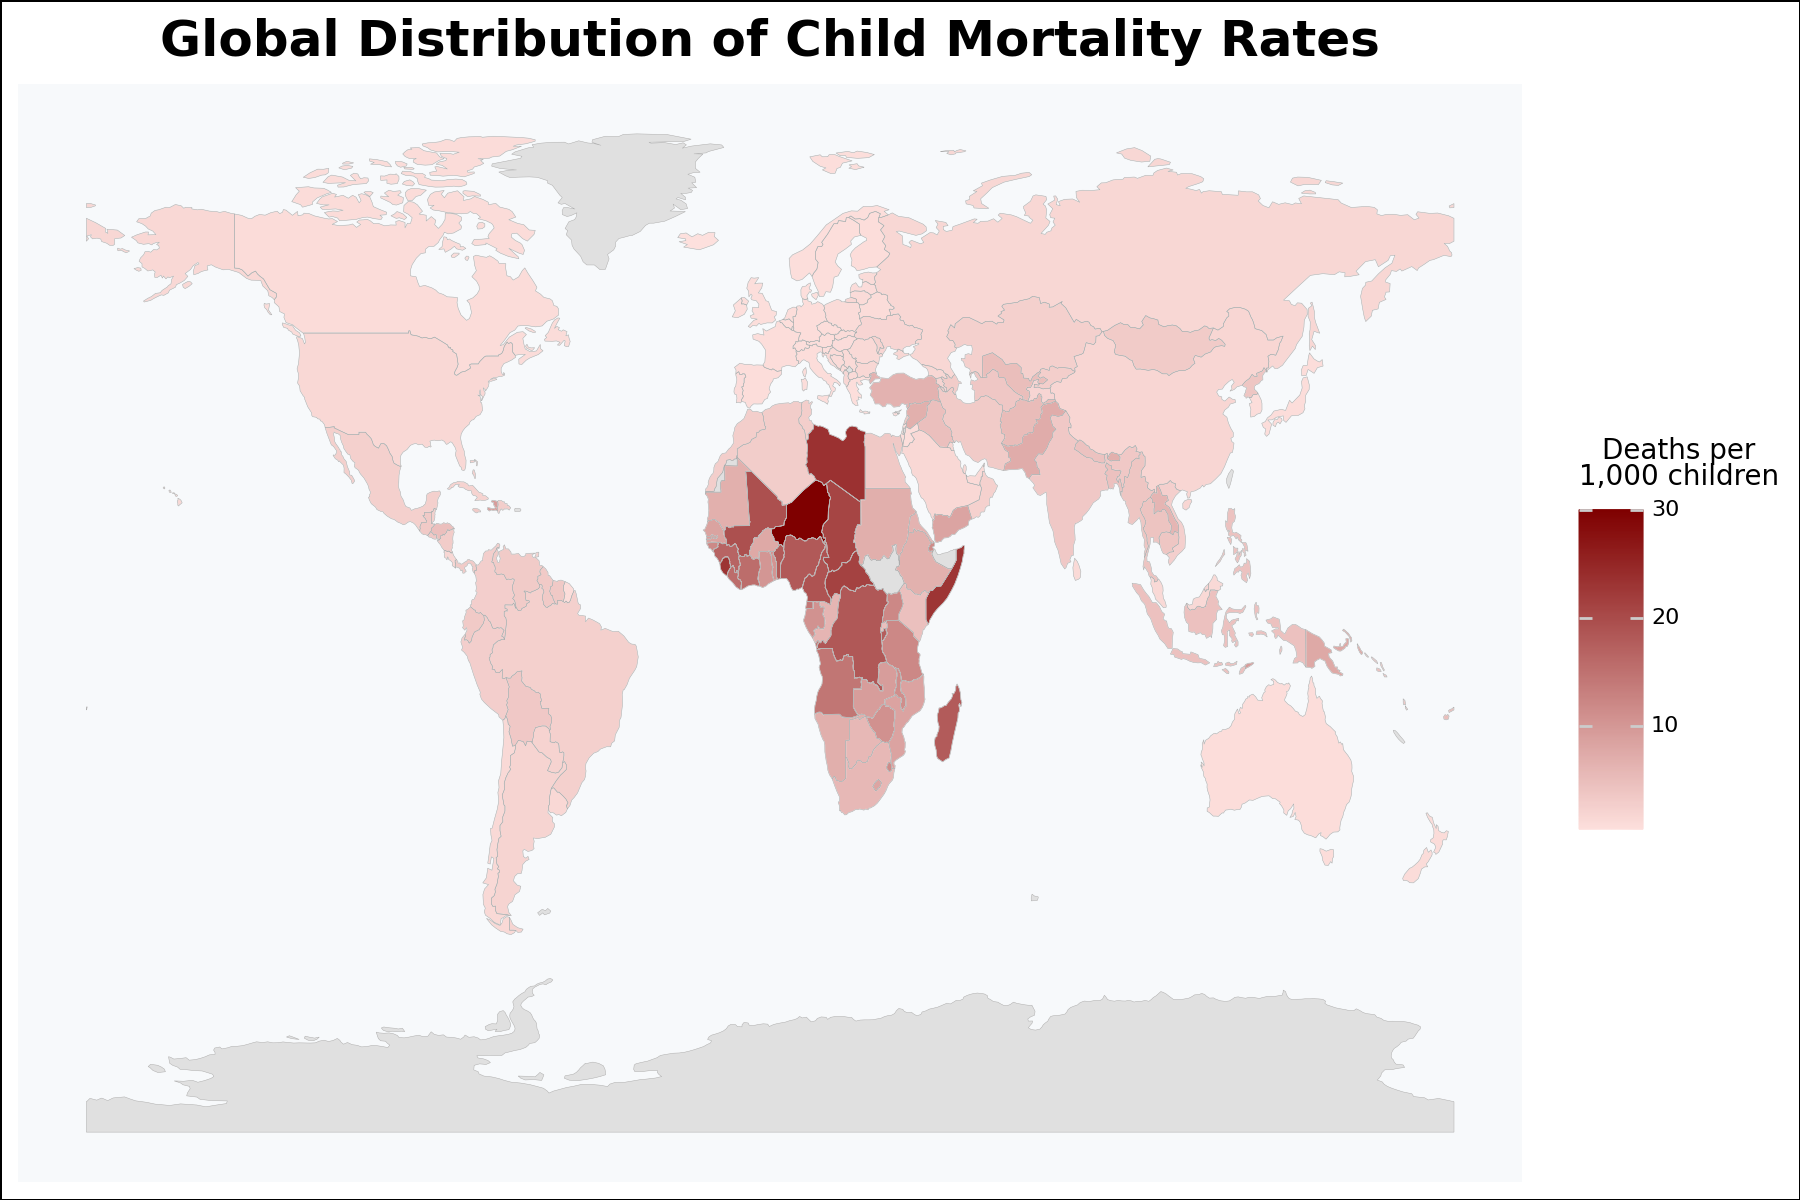

In [6]:
# #| label: fig-world-map
# #| fig-cap: "Global Distribution of Child Mortality Rates (latest data per country)"
# #| fig-width: 9
# #| fig-height: 6

# Download the Natural Earth 110m boundaries (low-res, fast)
# This fetch happens once; Quarto caches subsequent renders
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

map_pd = map_data.to_pandas()

# Merge on ISO alpha-3 code (handles country-name spelling variations)
world_merged = world.merge(
    map_pd[["alpha_3_code", "mortality_rate"]],
    left_on="ADM0_A3",
    right_on="alpha_3_code",
    how="left"
)

# Modern theme
map_theme = theme_minimal() + theme(
    figure_size=(9, 6),

    axis_text=element_blank(),
    axis_title=element_blank(),
    panel_grid=element_blank(),

    panel_background=element_rect(fill="#f7f9fb"),
    plot_background=element_rect(fill="white"),

    plot_title=element_text(size=18, weight="bold", ha="center"),

    legend_position="right",
    legend_title=element_text(size=10),
    legend_text=element_text(size=8),

    # remove panel border
    panel_border=element_blank()
)

# Plot
p_map = (
    ggplot(world_merged)

    # main fill layer
    + geom_map(
        aes(fill="mortality_rate"),
        color="#f0f0f0",      # softer borders
        size=0.15
    )

    # optional extra border layer for crisp look
    + geom_map(
        fill=None,
        color="#aaaaaa",
        size=0.1,
        alpha=0.5
    )

    # smoother modern gradient (reddish → dark)
    + scale_fill_gradient(
        low="#fde0dd",
        high="#7f0000",
        na_value="#e0e0e0",
        name="Deaths per\n1,000 children"
    )

    + labs(
        title="Global Distribution of Child Mortality Rates"
    )

    + map_theme
)

p_map

*Interactive map 👇*


In [7]:
import folium
import geopandas as gpd

# Load Natural Earth (same as your code)
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Convert polars → pandas
map_pd = map_data.to_pandas()

# Merge using ISO alpha-3 (KEEP this — it's perfect)
world_merged = world.merge(
    map_pd[["alpha_3_code", "mortality_rate"]],
    left_on="ADM0_A3",
    right_on="alpha_3_code",
    how="left"
)

# Create interactive map
m = folium.Map(location=[20, 0],
               zoom_start=2,
               tiles="cartodbpositron",
               width=800,
               height=500)

# Choropleth (key change: use ADM0_A3 instead of country names)
folium.Choropleth(
    geo_data=world_merged,
    data=world_merged,
    columns=["ADM0_A3", "mortality_rate"],
    key_on="feature.properties.ADM0_A3",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    legend_name="Deaths per 1,000 children"
).add_to(m)

# Tooltip (interactive hover)
folium.GeoJson(
    world_merged,
    tooltip=folium.GeoJsonTooltip(
        fields=["ADMIN", "mortality_rate"],
        aliases=["Country:", "Mortality Rate:"],
    )
).add_to(m)

m.save("map.html")

<div class="map-container">
<iframe src="map.html"
  style="  width: 100%;
    max-width: 900px;
    height: 500px;
    margin: auto;
    display: block;"></iframe>
</div>

## Identifying the Most Vulnerable Nations

Two separate rankings illustrate the crisis from complementary angles:

### Top 10 Countries by Child Mortality

**South Sudan** stands alone at the top with an average mortality rate of **73.3** - almost 30 points
higher than the next-ranked **Rwanda (44.8)**. Every country in this list is in Sub-Saharan Africa,
suggesting that **continent-level structural inequalities**, not just individual country failures are at play.

### Top 10 Countries by Deprivation Levels

The deprivation ranking tells a slightly different story. **Madagascar** and **Ethiopia** lead here,
with deprivation percentages of **1.43%** and **1.22%** respectively. These two lists overlap significantly,
but not perfectly hinting that **deprivation alone does not fully explain mortality**, and that
factors like conflict, geography, and healthcare infrastructure also play important roles.


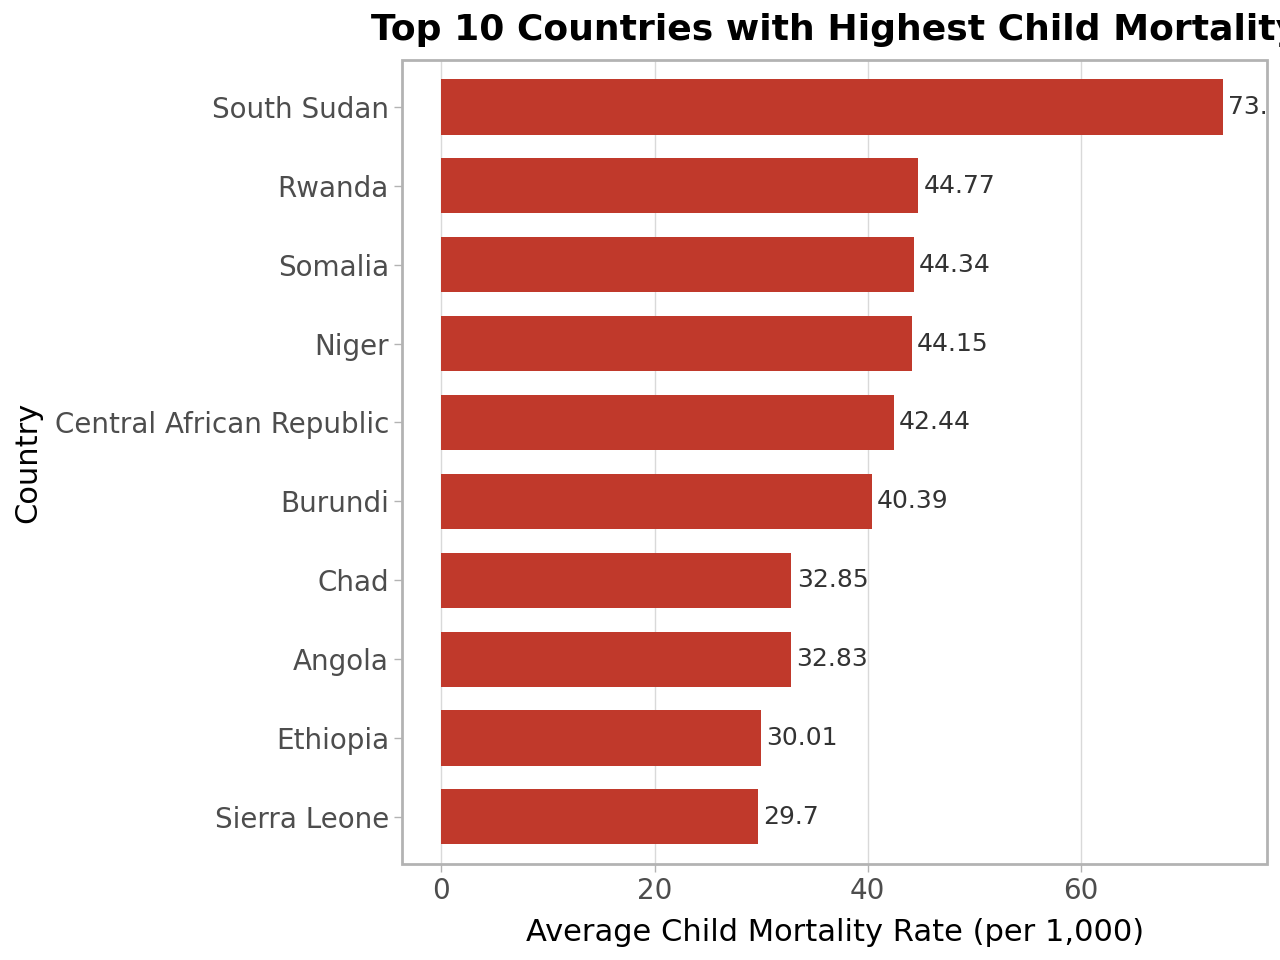

In [8]:
#| label: fig-bar-mortality
#| fig-cap: "Top 10 Countries with Highest Average Child Mortality Rate (All Years)"
#| fig-width: 9
#| fig-height: 5

bar_theme = theme(
    plot_title=element_text(size=13, face="bold"),
    axis_text=element_text(size=10),
    axis_title=element_text(size=11),
    panel_grid_major_y=element_blank(),
    panel_grid_minor=element_blank(),
    panel_background=element_rect(fill="white"),
    plot_background=element_rect(fill="white"),
)

top10_m_pd = top10_mortality.to_pandas()

p_bar_mort = (
    ggplot(top10_m_pd, aes(x="reorder(country, avg_mortality)", y="avg_mortality"))
    + geom_col(fill="#c0392b", width=0.7)
    + geom_text(
        aes(label="avg_mortality"),
        ha="left", nudge_y=0.5, size=9, color="#333333"
    )
    + coord_flip()
    + labs(
        title="Top 10 Countries with Highest Child Mortality",
        x="Country",
        y="Average Child Mortality Rate (per 1,000)"
    )
    + theme_light()
    + bar_theme
)

p_bar_mort


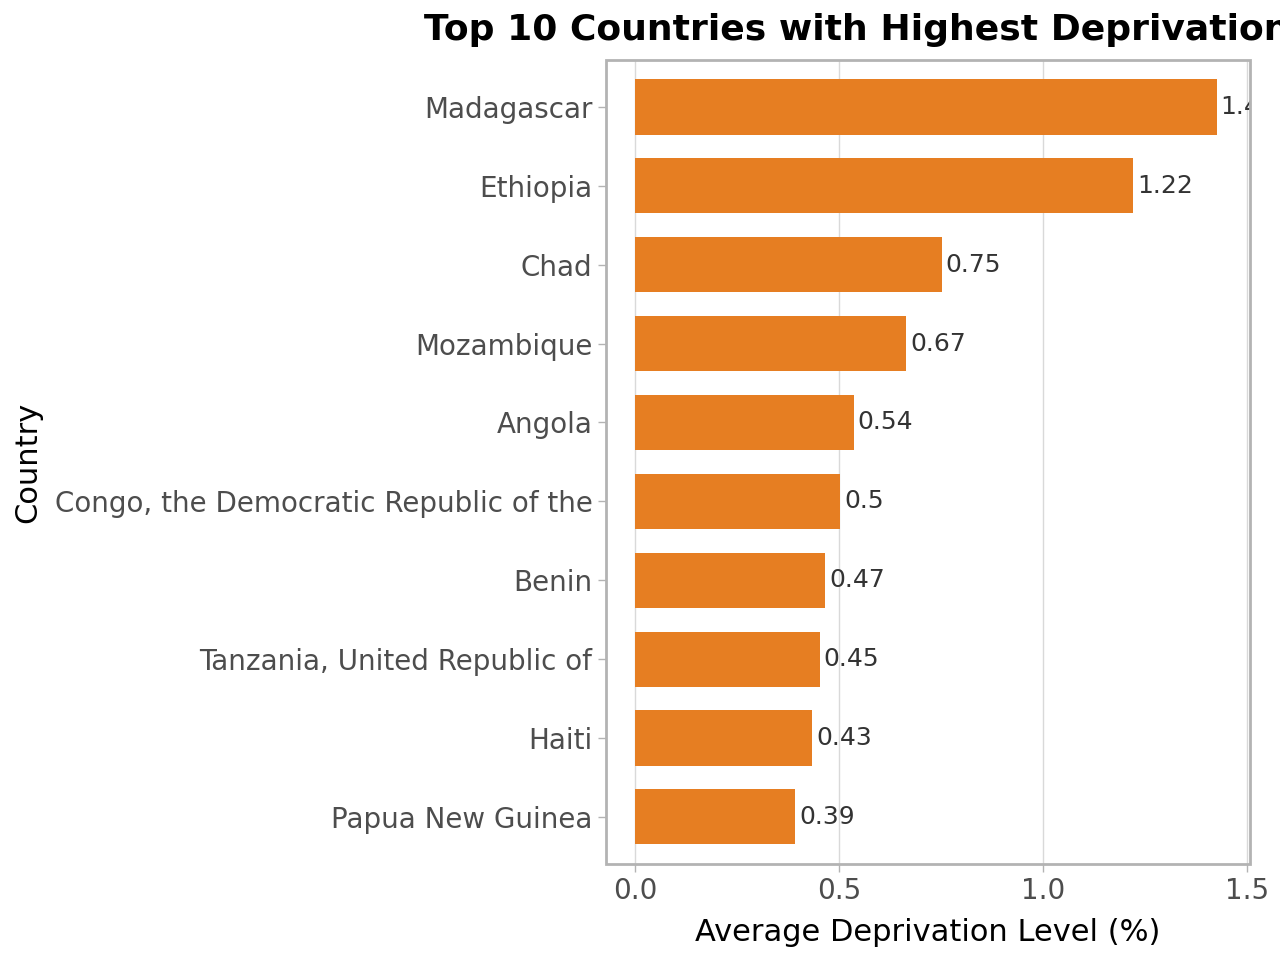

In [9]:
#| label: fig-bar-deprivation
#| fig-cap: "Top 10 Countries with Highest Deprivation Levels"
#| fig-width: 9
#| fig-height: 5

top10_d_pd = top10_deprivation.to_pandas()

p_bar_dep = (
    ggplot(top10_d_pd, aes(x="reorder(country, deprivation_pct)", y="deprivation_pct"))
    + geom_col(fill="#e67e22", width=0.7)
    + geom_text(
        aes(label="deprivation_pct.round(2)"),
        ha="left", nudge_y=0.01, size=9, color="#333333"
    )
    + coord_flip()
    + labs(
        title="Top 10 Countries with Highest Deprivation Levels",
        x="Country",
        y="Average Deprivation Level (%)"
    )
    + theme_light()
    + bar_theme
)

p_bar_dep


## The Deprivation–Mortality Link

The scatterplot below plots every country's **average child mortality rate** against its
**deprivation percentage**. A linear regression line confirms the positive relationship:

- Countries near the origin (low deprivation, low mortality) are almost universally **high-income nations**.
- As deprivation rises above **0.5%**, mortality rates begin climbing sharply.
- A handful of **outliers** (high mortality but moderate deprivation) often correspond to
  **conflict-affected states** where mortality spikes are driven by violence rather than structural poverty alone.

This is a powerful argument for **integrated interventions** that address both economic deprivation
and security simultaneously.


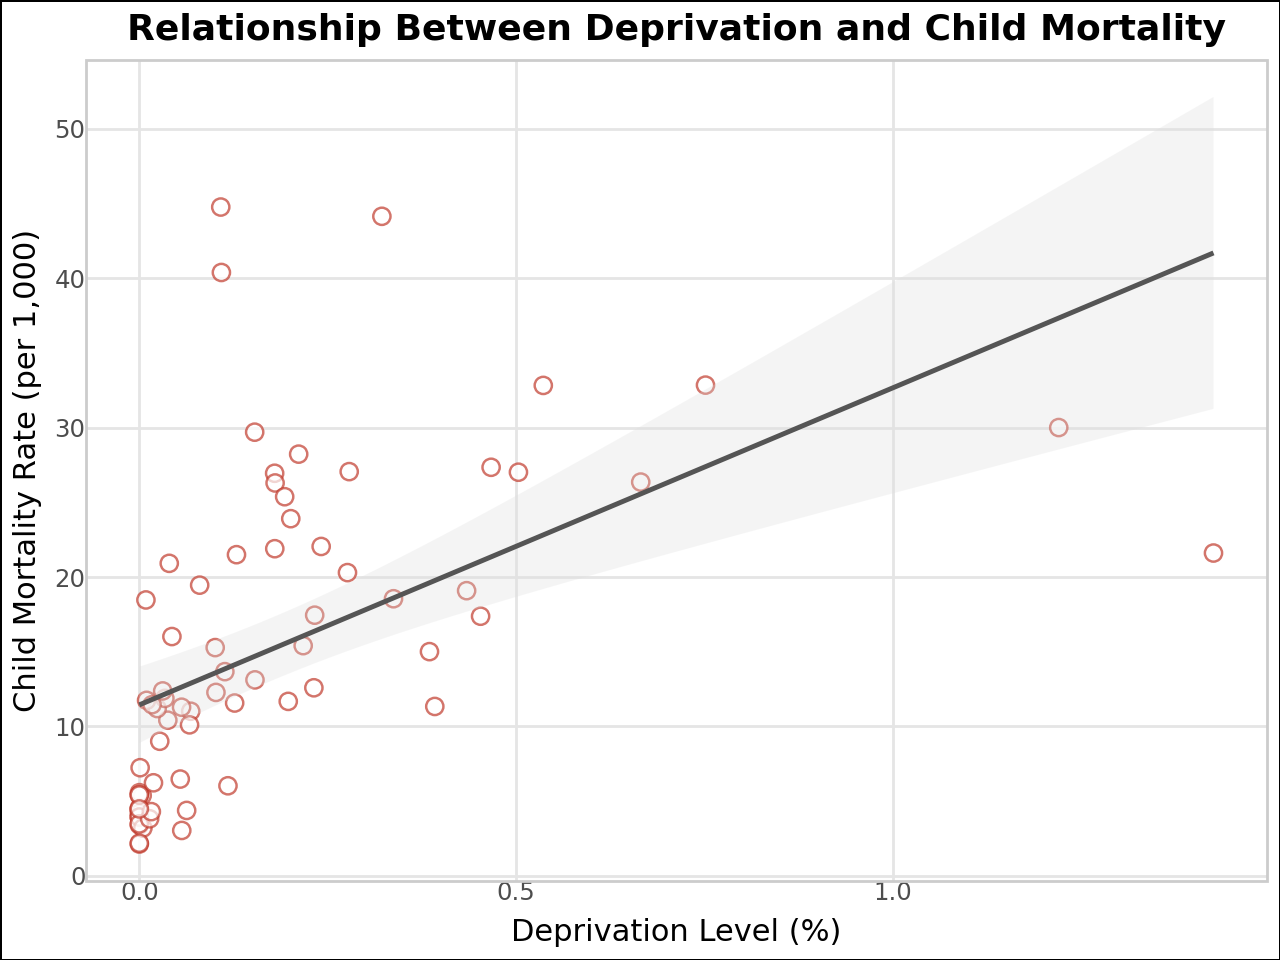

In [10]:
#| label: fig-scatter
#| fig-cap: "Relationship Between Deprivation and Child Mortality (country averages)"
#| fig-width: 9
#| fig-height: 6

scatter_pd = scatter_data.to_pandas()

p_scatter = (
    ggplot(scatter_pd, aes(x="deprivation_pct", y="avg_mortality"))
    + geom_point(color="#c0392b", fill="white", alpha=0.7, size=3, shape="o")
    + geom_smooth(method="lm", color="#555555", fill="#dddddd", alpha=0.3, size=1)
    + scale_x_continuous(name="Deprivation Level (%)")
    + scale_y_continuous(name="Child Mortality Rate (per 1,000)")
    + labs(title="Relationship Between Deprivation and Child Mortality")
    + theme_minimal()
    + theme(
        plot_title=element_text(size=13, face="bold"),
        panel_grid_minor=element_blank(),
        panel_border=element_rect(color="#cccccc"),
        plot_background=element_rect(fill="white"),
    )
)

p_scatter


## Trends Over Time: Progress and Pain

### The Global Picture: Steady Decline

The global average child mortality rate has fallen dramatically - from **~14 deaths per 1,000 in 1990**
down to a record low of **5.14 in 2023**. This represents roughly a **63% reduction** in three decades,
a genuine triumph of global public health policy, vaccination drives, and economic development.

However, averages can mislead. The chart below for individual high-risk nations reveals that
this progress has been anything but smooth.

### High-Risk Countries: Volatility Beneath the Average

Three countries reveal the limits of aggregate progress:

- **Rwanda**: The catastrophic 1994 spike to **339 deaths per 1,000** - caused by the genocide
  is one of the most dramatic single-year deteriorations ever recorded in child health data.
  Rwanda has since made *remarkable* progress, now approaching the global average.
- **South Sudan**: Shows extreme volatility through the 1990s during civil conflict, followed by
  a decline, but remains dangerously high.
- **Somalia**: Another conflict-driven outlier with spikes in the early 1990s during its civil war,
  with persistent elevated rates that reflect ongoing instability.


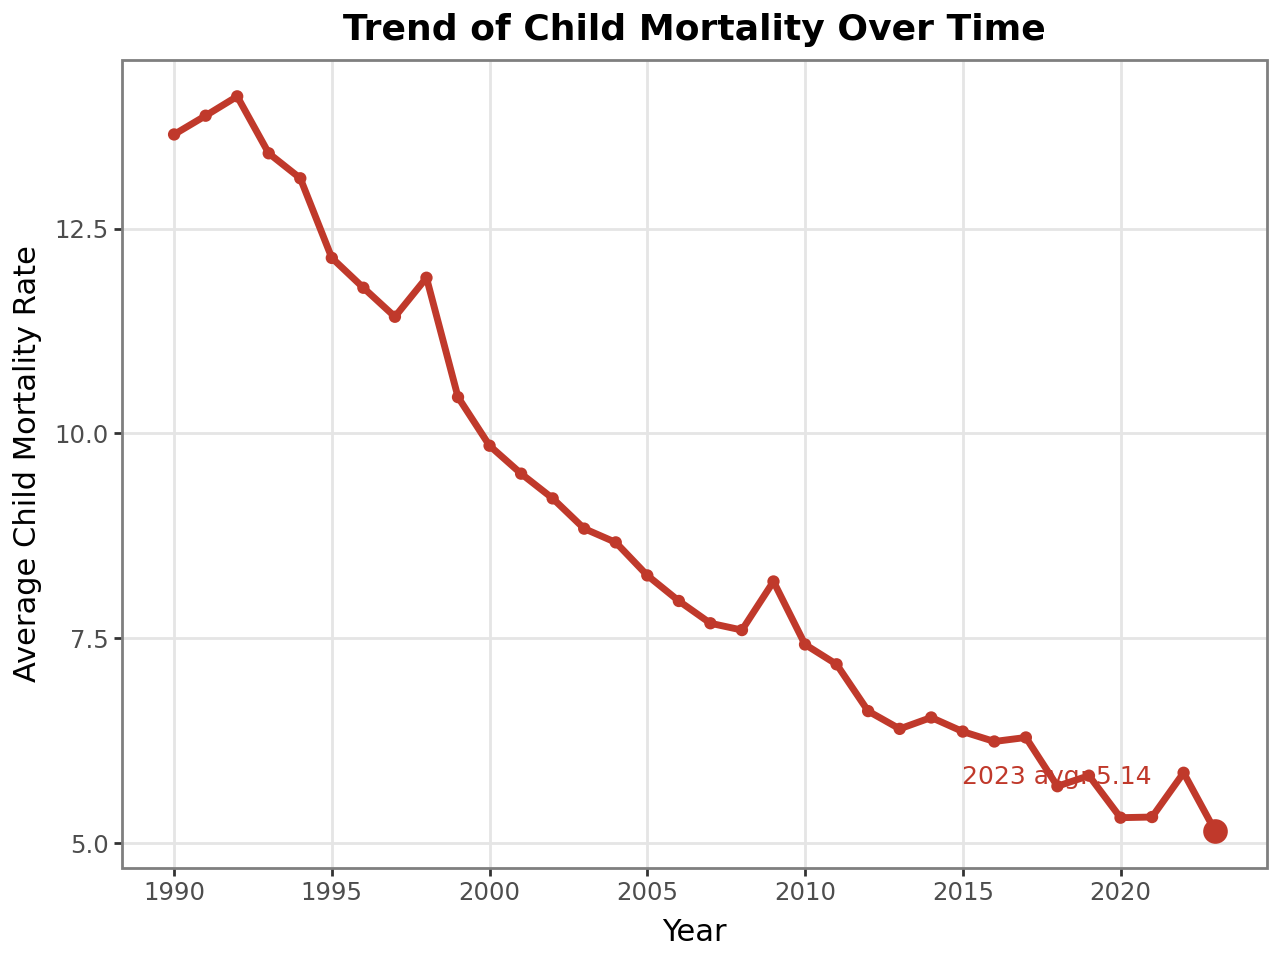

In [11]:
#| label: fig-timeseries-global
#| fig-cap: "Global Trend of Average Child Mortality (1990–2023)"
#| fig-width: 10
#| fig-height: 5

global_pd = global_trend.to_pandas()

p_trend = (
    ggplot(global_pd, aes(x="time_period", y="avg_mortality"))
    + geom_line(color="#c0392b", size=1.4)
    + geom_point(color="#c0392b", size=1.5)
    + annotate(
        "text", x=2021, y=5.8,
        label="2023 avg: 5.14",
        color="#c0392b", size=9, ha="right"
    )
    + annotate(
        "point", x=2023, y=5.141, size=4, color="#c0392b"
    )
    + scale_x_continuous(breaks=list(range(1990, 2025, 5)))
    + labs(
        title="Trend of Child Mortality Over Time",
        x="Year",
        y="Average Child Mortality Rate"
    )
    + theme_bw()
    + theme(
        plot_title=element_text(size=13, face="bold"),
        panel_grid_minor=element_blank(),
        plot_background=element_rect(fill="white"),
    )
)

p_trend


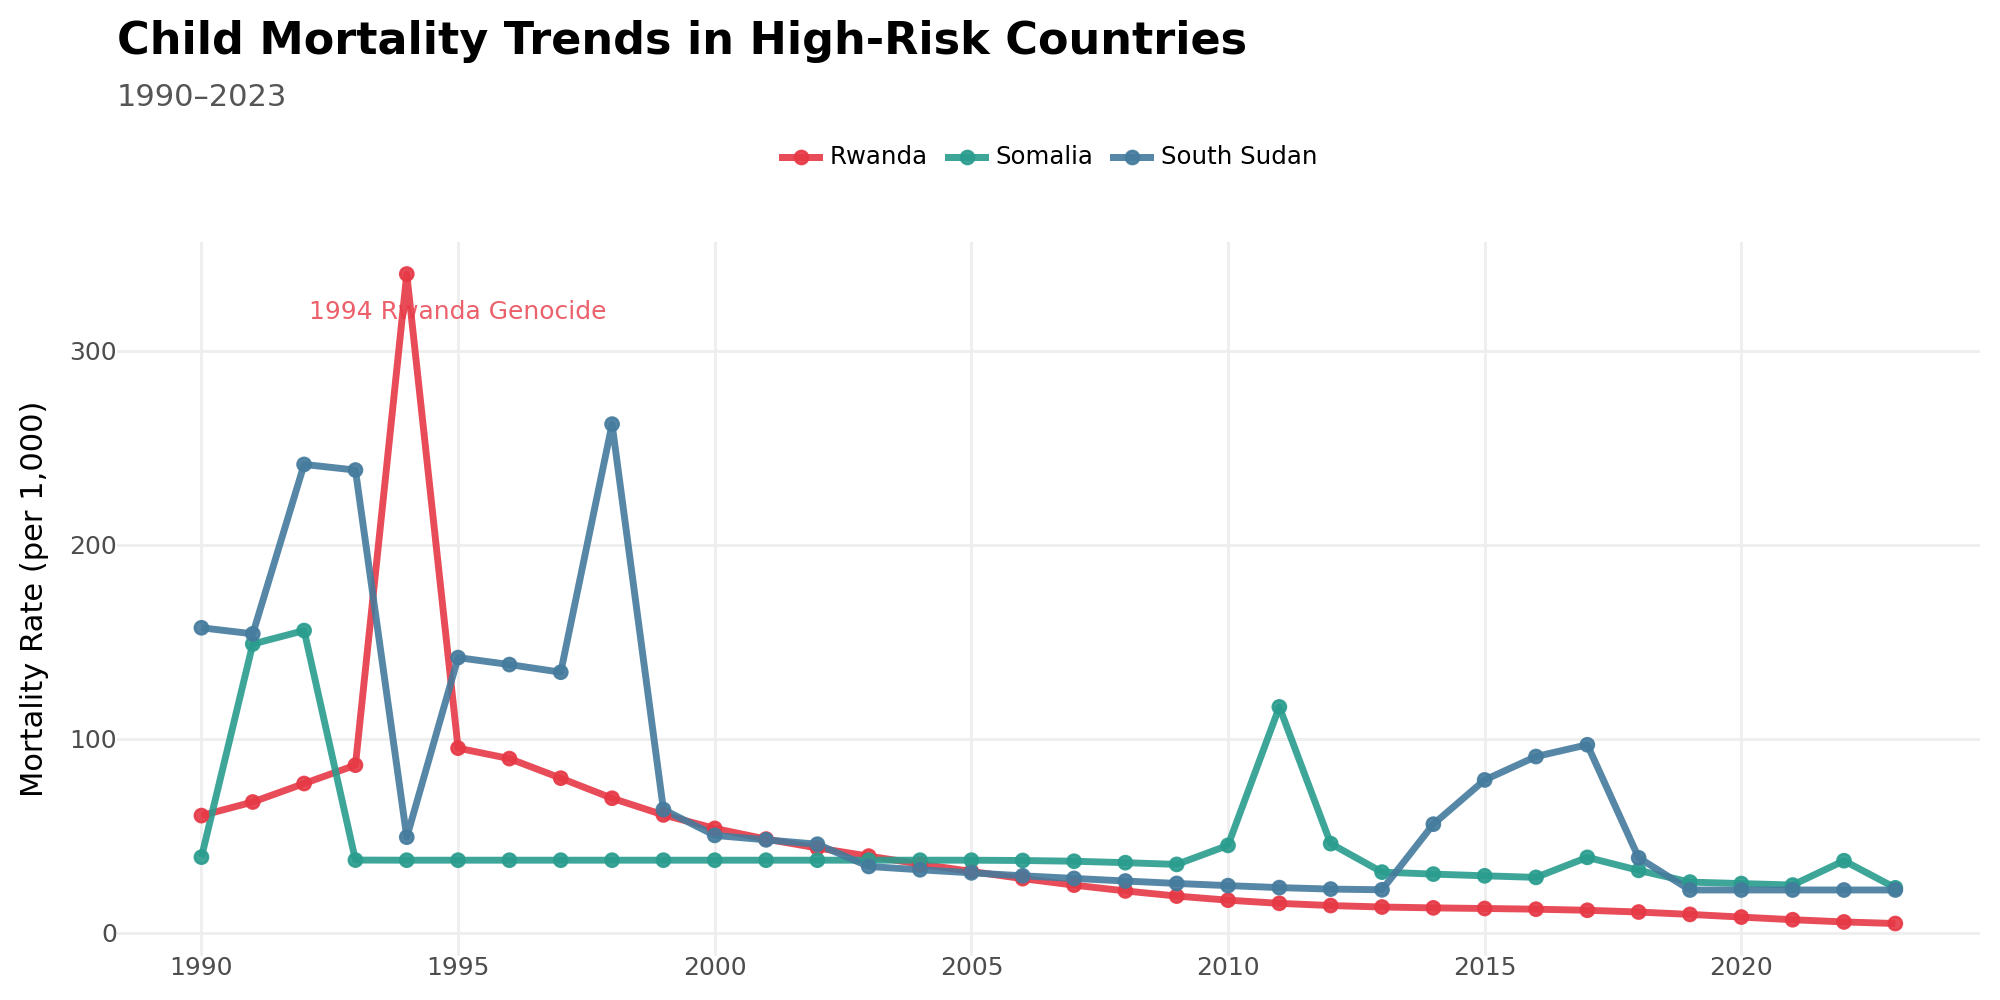

In [12]:
# #| label: fig-timeseries-highrisk
# #| fig-cap: "Child Mortality Trends in Highest-Risk Countries (1990–2023)"
# #| fig-width: 15
# #| fig-height: 5

hr_pd = high_risk_trend.to_pandas()

p_highrisk = (
    ggplot(hr_pd, aes(x="time_period", y="avg_mortality", color="country"))

    # smoother, modern lines
    + geom_line(size=1.4, alpha=0.9)
    + geom_point(size=2.2, alpha=0.9)

    # better color palette
    + scale_color_manual(
        values={
            "Rwanda": "#e63946",
            "Somalia": "#2a9d8f",
            "South Sudan": "#457b9d"
        },
        name="Country"
    )

    # cleaner x-axis
    + scale_x_continuous(breaks=list(range(1990, 2025, 5)))

    # softer annotation
    + annotate(
        "text", x=1995, y=320,
        label="1994 Rwanda Genocide",
        color="#e63946", size=9, alpha=0.8
    )

    # titles
    + labs(
        title="Child Mortality Trends in High-Risk Countries",
        subtitle="1990–2023",
        x="",
        y="Mortality Rate (per 1,000)"
    )

    # MODERN THEME
    + theme_minimal()
    + theme(
        figure_size=(10, 5),

        # typography
        plot_title=element_text(size=16, face="bold"),
        plot_subtitle=element_text(size=11, color="#555"),
        axis_text=element_text(size=9),

        # grid cleanup
        panel_grid_minor=element_blank(),
        panel_grid_major=element_line(color="#eeeeee"),

        # legend
        legend_position="top",
        legend_title=element_blank(),

        # spacing
        # plot_margin={"t": 10, "r": 10, "b": 10, "l": 10}
    )
)

p_highrisk

## Conclusion: From Data to Action

The data tells a story of **profound inequality** and **fragile progress**. Three decades of concerted
global effort have cut the average child mortality rate by nearly two-thirds — from 14 to 5.14.
Yet for a child born in **South Sudan**, the odds of surviving to age 15 remain tragically low.

### Key takeaways

| Insight | Evidence |
|---|---|
| Geography is destiny | All top-10 mortality countries are in Sub-Saharan Africa |
| Deprivation predicts mortality | Positive linear relationship (r² > 0 with wide variance) |
| Conflict erases progress | Rwanda's 1994 spike: 60 → 339 → back to ~3 today |
| Progress is achievable | Global average dropped 63% in 33 years |

### UNICEF's call to action
::: {}                                         
1. **Target the 'Bottom 10'** with emergency nutrition, clean water, and healthcare investment.
2. **Integrate economic aid with healthcare** - deprivation and mortality are inseparable.
3. **Protect children in conflict zones** - no amount of development aid can survive an active war.
4. **Close the data gap** - grey regions on the world map represent children we cannot yet count.
:::

---


:::{.callout-important}
Every decimal point in this data represents a child's life. Turning these statistics into action is not a moral option — it is a moral obligation.
:::

---
*Data sources: UNICEF Indicator datasets on child mortality and multidimensional deprivation,
and UNICEF country metadata. Analysis performed in Python using Polars and Plotnine.*

In [14]:
#| output: false
!quarto render "/content/drive/MyDrive/Colab Notebooks/report.ipynb"

pandoc 
  to: html
  output-file: report.html
  standalone: true
  embed-resources: true
  section-divs: true
  html-math-method: mathjax
  wrap: none
  default-image-extension: png
  toc: true
  toc-depth: 3
  variables: {}
  
metadata
  document-css: false
  link-citations: true
  date-format: long
  lang: en
  engines:
    - path: /usr/local/lib/python3.12/dist-packages/quarto_cli/share/extension-subtrees/julia-engine/_extensions/julia-engine/julia-engine.js
  title: The Silent Crisis
  subtitle: Global Child Deprivation and Mortality - A UNICEF Data Story
  author: Shashank Ramesh
  date: '2026-04-14'
  theme: pulse
  toc-title: Report Contents
  
[WARNING] Could not fetch resource map.html
Output created: report.html

